                 Bank Marketing Dataset
                          │
                          ↓
                    Train / Test Split
                          │
             ┌────────────┴────────────┐
             ↓                         ↓
          Training                    Test
             │                         │
             ↓                         │
       Cross Validation                │
             │                         │
       ┌─────┼─────┐                   │
       ↓     ↓     ↓                   │
     Fold1 Fold2 Fold3                 │
       │     │     │                   │
       ↓     ↓     ↓                   │
      HPO evaluates here               │
             │                         │
             ↓                         │
       Best Hyperparameters            │
             │                         │
             ↓                         │
       Final Model ────────────────────→ Test
                                       │
                                       ↓
                                  Final Metrics

# Stage 6 — Hyperparameter Optimization: Complete Research Documentation

## 1. Objective of Stage 6

Stage 6 investigates whether Hyperparameter Optimization (HPO) can improve the performance of machine-learning models for the imbalanced UCI Bank Marketing classification problem.

The target variable is `y`.

- `0` = customer did not subscribe to a term deposit
- `1` = customer subscribed to a term deposit

The dataset is imbalanced, with the positive class representing approximately 11.7% of the observations.

Because of this imbalance, accuracy alone is not sufficient for evaluating model quality.

The primary optimization objective in Stage 6 is the F1-score of the positive/minority class.

---

## 2. What is Hyperparameter Optimization?

Machine-learning models contain parameters that are learned from the data and hyperparameters that are selected before training.

Examples include:

- Logistic Regression → `C`
- Decision Tree → `max_depth`
- Random Forest → `n_estimators`
- Random Forest → `max_features`

Hyperparameter Optimization automatically searches through possible combinations of these settings and identifies configurations that perform well according to a predefined objective.

In this project, Optuna is used as the HPO framework.

---

## 3. Why HPO is important for this research

A default model uses predefined library settings.

For example, a Random Forest can be trained without explicitly tuning:

- number of trees
- tree depth
- minimum samples per split
- minimum samples per leaf
- feature-selection strategy
- class weighting

However, the default configuration is not necessarily the most appropriate configuration for an imbalanced classification problem.

Stage 6 therefore investigates whether systematic hyperparameter search can improve minority-class performance.

---

## 4. Models investigated

Three model families are optimized.

### Logistic Regression

Important hyperparameters:

- `C`
- `class_weight`

Logistic Regression provides a relatively simple and interpretable baseline model.

### Decision Tree

Important hyperparameters:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`
- `criterion`
- `class_weight`

### Random Forest

Important hyperparameters:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`
- `class_weight`

Random Forest is particularly useful for studying nonlinear relationships and feature interactions in tabular data.

---

## 5. Why class_weight is included in HPO

Class weighting is an imbalance-handling technique.

When `class_weight="balanced"` is used, the model gives greater importance to the minority class during training.

Instead of manually deciding whether class weighting should be used, Stage 6 allows Optuna to investigate:

- `None`
- `"balanced"`

Therefore, class weighting itself becomes part of the hyperparameter search.

This connects Stage 5 and Stage 6.

Stage 5 studied imbalance strategies explicitly.

Stage 6 investigates whether the optimization process can identify a useful imbalance-aware configuration.

---

## 6. Cross-validation design

The training dataset is evaluated using three-fold Stratified Cross-Validation.

Stratification ensures that each fold maintains approximately the same class distribution as the complete training set.

For each Optuna trial:

1. A hyperparameter configuration is generated.
2. The training data is divided into three folds.
3. The model is trained using two folds.
4. The remaining fold is used for validation.
5. This process is repeated three times.
6. The three F1-scores are averaged.
7. Optuna uses the average F1-score as the trial objective.

The test dataset is not used during this optimization process.

---

## 7. Data leakage prevention

Data leakage occurs when information from validation or test data influences model training.

This would make the reported performance unreliable.

The preprocessing operations are therefore placed inside the machine-learning Pipeline.

The intended sequence is:

Training fold
→ preprocessing fitting
→ model training
→ validation fold transformation
→ validation prediction

The validation fold does not determine the preprocessing parameters.

The final test set remains untouched until the optimized hyperparameters have been selected.

This is essential for a research-quality experiment.

---

## 8. Why F1-score is initially optimized

The positive class is the minority class.

If the model predicts almost every customer as class 0, it can obtain high accuracy while failing to identify customers who actually subscribe.

F1-score combines:

- Precision
- Recall

and is therefore more informative than accuracy when the positive class is important.

However, F1 is not the only possible objective.

Stage 7 will investigate multi-objective optimization involving metrics such as:

- F1
- Recall
- PR-AUC
- Balanced Accuracy

This allows the research to study whether different optimization objectives produce different model behaviors.

---

## 9. Why PR-AUC is reported

Precision-Recall analysis is particularly informative for imbalanced classification.

PR-AUC summarizes the relationship between:

- Precision
- Recall

across different classification thresholds.

Unlike accuracy, PR-AUC focuses directly on positive-class retrieval behavior.

Therefore, PR-AUC is reported as an evaluation metric even though F1 is the initial HPO objective.

---

## 10. Why ROC-AUC is also reported

ROC-AUC measures the ability of the classifier to distinguish between the two classes across classification thresholds.

It provides a useful general discrimination measure.

However, because the dataset is imbalanced, ROC-AUC should not be interpreted alone.

Therefore, the research reports ROC-AUC together with:

- PR-AUC
- Recall
- Precision
- F1
- Balanced Accuracy

---

## 11. Why balanced accuracy is reported

Balanced Accuracy considers performance on both classes rather than allowing the majority class to dominate the metric.

It is calculated from the average of sensitivity and specificity.

This provides another perspective on whether the classifier performs reasonably across both classes.

---

## 12. Default model versus HPO model

Stage 4 established default-model baselines.

Stage 6 produces optimized versions of the same model families.

Therefore, the experimental comparison is:

Default Logistic Regression
versus
HPO Logistic Regression

Default Decision Tree
versus
HPO Decision Tree

Default Random Forest
versus
HPO Random Forest

This allows us to measure whether optimization actually provides measurable improvement.

---

## 13. Optuna optimization history

The optimization-history graphs show how the validation F1-score changes across trials.

Each point represents an Optuna trial.

The purpose is not simply to find the largest point visually.

The history allows us to investigate whether:

- performance improves during optimization
- good configurations are discovered early
- performance becomes stable
- the search remains variable
- additional trials might be useful

---

## 14. Hyperparameter importance

Optuna provides an estimate of how strongly each searched hyperparameter contributes to the observed objective values.

This is useful because the research question is not only:

"Which hyperparameters produced the best model?"

It is also:

"Which hyperparameters were important during optimization?"

For example, Random Forest optimization may indicate that parameters such as tree depth or minimum leaf size are influential.

The actual importance values must be obtained from the experiment and must not be fabricated.

---

## 15. Test-set evaluation

After HPO has selected the best hyperparameters using cross-validation on the training data, the optimized model is retrained on the complete training dataset.

Only then is the model evaluated on the untouched test dataset.

The test set provides the final independent performance estimate.

The following metrics are reported:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Balanced Accuracy

---

## 16. Relationship with Stage 5

Stage 5 studied explicit imbalance strategies:

- original training data
- class weighting
- SMOTENC

Stage 6 now studies hyperparameter optimization.

Class weighting is allowed to participate in the HPO search.

This creates an important connection:

Stage 5:
"What happens when we use different imbalance strategies?"

Stage 6:
"Can HPO identify useful model and class-weight configurations?"

Stage 7:
"How does the choice of optimization objective affect the optimized solution?"

---

## 17. Important limitation

Stage 6 currently optimizes one primary objective: F1-score.

Therefore, the optimized model is not automatically the best model for every possible business objective.

For example:

- maximizing recall may produce a different model
- maximizing PR-AUC may produce a different model
- maximizing balanced accuracy may produce a different model

This limitation motivates Stage 7.

---

## 18. Research significance

Stage 6 provides an experimental foundation for the proposed explainable HPO framework.

The research can now investigate:

1. Whether default hyperparameters are sufficient.
2. Whether HPO improves minority-class performance.
3. Which hyperparameters are influential.
4. Whether different models respond differently to HPO.
5. Whether class weighting is selected by the optimization process.
6. Whether HPO improvements are consistent across evaluation metrics.

These findings will later be combined with threshold optimization, robustness analysis, and explainability.

---

## 19. Important methodological rule

The final research paper must report the exact experimental configuration.

This includes:

- dataset
- train/test split
- random seed
- cross-validation strategy
- number of Optuna trials
- hyperparameter search spaces
- optimization objective
- evaluation metrics
- preprocessing procedure
- model configurations

This makes the experiment reproducible.

---

## 20. Connection to the overall research framework

The complete research pipeline is now:

Data Understanding
↓
EDA and Imbalance Analysis
↓
Leakage-Safe Preprocessing
↓
Default Baseline Models
↓
Imbalance Strategies
↓
Hyperparameter Optimization
↓
Multi-Objective HPO
↓
Threshold Optimization
↓
Robustness Analysis
↓
SHAP Explainability
↓
Explanation Stability
↓
Final Experimental Analysis

Stage 6 therefore represents the transition from conventional model training to systematic optimization.

---

## 21. Expected outputs

Stage 6 produces:

- optimized Logistic Regression
- optimized Decision Tree
- optimized Random Forest
- best hyperparameter configurations
- Optuna trial histories
- hyperparameter importance results
- HPO test metrics
- default versus HPO comparisons
- F1 comparison
- PR-AUC comparison
- Recall comparison
- saved CSV result files

These outputs will be used by later stages.

---

## 22. Files generated

The experiment saves results under:

`results/metrics/`

and:

`results/hpo/`

Important files include:

- `hpo_results.csv`
- `best_trial_summary.csv`
- `logistic_trials.csv`
- `decision_tree_trials.csv`
- `random_forest_trials.csv`

These files make it easier to reproduce the tables used later in the research paper.

---

## 23. What Stage 6 does NOT claim

Stage 6 does not claim that HPO automatically produces the best possible model.

It evaluates a defined search space and a defined optimization objective.

The result is therefore specific to:

- the dataset
- the search space
- the validation strategy
- the optimization objective
- the trial budget
- the random seed

This distinction is important when presenting research conclusions.

---

## 24. Final purpose of Stage 6

The purpose of Stage 6 is to establish a rigorous HPO experiment before moving to multi-objective optimization.

The central research question is:

> Does systematic hyperparameter optimization improve imbalanced binary classification performance compared with default model configurations?

The answer must be determined from the experimental results rather than assumed in advance.

Stage 7 will extend this experiment by investigating multiple objectives simultaneously.

In [4]:
# ============================================================
# CELL 1 — PACKAGE INSTALLATION / VERIFICATION
# ============================================================

%pip install -U optuna imbalanced-learn scikit-learn plotly pandas numpy


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 4.7 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/8.2 MB 2.3 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.2 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.2 MB 1.5 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.2 MB 1.5 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.2 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.2 MB 1.3 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.2 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.2 MB 1.0 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.2 MB 1.0 MB/s eta 0:00:06
   ----------- ---------------------------- 2.4/8.2 MB 999.7 kB/s eta 0:00:06
   ----------- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.4.6 which is incompatible.
streamlit 1.45.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.6 which is incompatible.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [5]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import optuna
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

print("All required libraries imported successfully!")
print("Optuna version:", optuna.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

All required libraries imported successfully!
Optuna version: 5.0.0
Pandas version: 2.2.3
NumPy version: 2.1.3


In [2]:
import optuna

print("Optuna version:", optuna.__version__)

Optuna version: 5.0.0


In [6]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import optuna
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

print("All required libraries imported successfully!")
print("Optuna version:", optuna.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
# ============================================================
# CELL 3 — LOAD DATASET
# ============================================================

data_path = "../data/raw/bank-full.csv"

df = pd.read_csv(data_path)

print("=" * 80)
print("STAGE 6 — HYPERPARAMETER OPTIMIZATION")
print("=" * 80)

print("\nDataset loaded successfully!")

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

All required libraries imported successfully!
Optuna version: 5.0.0
Pandas version: 2.2.3
NumPy version: 2.1.3
STAGE 6 — HYPERPARAMETER OPTIMIZATION

Dataset loaded successfully!

Dataset shape:
(45211, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

First five rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
1,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
2,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
3,18,student,single,unknown,no,35,no,no,telephone,21,aug,104,2,-1,0,unknown,no
4,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no


In [7]:
# ============================================================
# CELL 4 — FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["y"]).copy()

y = df["y"].map({
    "no": 0,
    "yes": 1
})

if y.isna().any():
    raise ValueError(
        "Target encoding produced missing values. "
        "Check the original y column."
    )

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True).sort_index() * 100).round(2)
)

print("\nUnique target values:")
print(sorted(y.unique()))

Features shape: (45211, 16)
Target shape: (45211,)

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64

Target percentage:
y
0    88.3
1    11.7
Name: proportion, dtype: float64

Unique target values:
[np.int64(0), np.int64(1)]


In [8]:
# ============================================================
# CELL 4 — FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["y"]).copy()

y = df["y"].map({
    "no": 0,
    "yes": 1
})

if y.isna().any():
    raise ValueError(
        "Target encoding produced missing values. "
        "Check the original y column."
    )

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True).sort_index() * 100).round(2)
)

print("\nUnique target values:")
print(sorted(y.unique()))

Features shape: (45211, 16)
Target shape: (45211,)

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64

Target percentage:
y
0    88.3
1    11.7
Name: proportion, dtype: float64

Unique target values:
[np.int64(0), np.int64(1)]


In [9]:
# ============================================================
# CELL 5 — FEATURE TYPE IDENTIFICATION
# ============================================================

numerical_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numerical_columns)

print("\nNumber of numerical features:")
print(len(numerical_columns))

print("\nCategorical features:")
print(categorical_columns)

print("\nNumber of categorical features:")
print(len(categorical_columns))

print("\nTotal features:")
print(
    len(numerical_columns) +
    len(categorical_columns)
)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Number of numerical features:
7

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Number of categorical features:
9

Total features:
16


In [10]:
# ============================================================
# CELL 6 — TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}

print("\n✓ Stratified split completed.")
print("✓ Test set is separated from HPO.")

Training data:
X_train: (36168, 16)
y_train: (36168,)

Testing data:
X_test: (9043, 16)
y_test: (9043,)

Training target distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Testing target distribution:
y
0    7985
1    1058
Name: count, dtype: int64

✓ Stratified split completed.
✓ Test set is separated from HPO.


In [11]:
# ============================================================
# CELL 7 — LEAKAGE-SAFE PREPROCESSING
# ============================================================

numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_columns
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ]
)

print("Preprocessing pipeline created successfully!")
print("\nNumerical transformation:")
print("StandardScaler")

print("\nCategorical transformation:")
print("OneHotEncoder(handle_unknown='ignore')")

Preprocessing pipeline created successfully!

Numerical transformation:
StandardScaler

Categorical transformation:
OneHotEncoder(handle_unknown='ignore')


In [12]:
# ============================================================
# CELL 8 — STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print(cv)

print("\nNumber of folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

print("\n✓ Stratified CV preserves class proportions.")

Cross-validation strategy:
StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

Number of folds: 3
Shuffle: True
Random state: 42

✓ Stratified CV preserves class proportions.


# Stage 6 — Hyperparameter Optimization

## What is Hyperparameter Optimization?

A machine-learning model has two different types of parameters.

### Parameters

Parameters are learned automatically from the training data.

For example, Logistic Regression learns model coefficients during training.

### Hyperparameters

Hyperparameters are settings that we choose before training.

Examples include:

- Logistic Regression → C
- Decision Tree → max_depth
- Random Forest → n_estimators
- Random Forest → max_depth

Choosing these values manually can be inefficient.

Hyperparameter Optimization (HPO) automatically searches through possible combinations and identifies configurations that perform well according to a selected objective.

---

## Why HPO is important for our research

Our research is not simply asking:

> Which model gives the highest accuracy?

Our dataset is imbalanced:

- approximately 88.3% belong to class 0
- approximately 11.7% belong to class 1

Therefore, accuracy alone can hide poor minority-class performance.

For Stage 6, we use F1-score as the primary optimization objective because F1 balances:

- Precision
- Recall

for the positive/minority class.

Later, Stage 7 will investigate multiple optimization objectives such as:

- F1
- Recall
- PR-AUC
- Balanced Accuracy

This allows us to study how the choice of optimization objective affects the resulting model.

---

## Why we use cross-validation

We do not want Optuna to select hyperparameters based on a single validation split.

Instead, the training data is divided into three stratified folds.

For each trial:

1. The model is trained on two folds.
2. The model is evaluated on the remaining fold.
3. The process is repeated three times.
4. The three F1 scores are averaged.
5. Optuna uses this average as the trial score.

The test set is not used during optimization.

---

## Leakage prevention

The preprocessing pipeline is fitted separately inside each cross-validation training fold.

Therefore:

Training fold → preprocessing fit → model training

Validation fold → preprocessing transform → validation

The validation fold does not influence preprocessing parameters.

The final test set remains untouched until the end of the HPO experiment.

---

## Research purpose

Stage 6 investigates whether optimized hyperparameters improve the performance of our Bank Marketing classifiers compared with their default configurations.

The experiment also allows us to examine which hyperparameters are most influential in the optimization process.

In [14]:
# ============================================================
# CELL 10 — HPO OBJECTIVE METRIC
# ============================================================

HPO_SCORING = "f1"

print("Primary HPO objective:", HPO_SCORING)

print("""
F1-score is used because the Bank Marketing target is imbalanced.

F1 combines:
    Precision
    Recall

The test set will NOT be used during optimization.
""")

Primary HPO objective: f1

F1-score is used because the Bank Marketing target is imbalanced.

F1 combines:
    Precision
    Recall

The test set will NOT be used during optimization.



In [15]:
# ============================================================
# CELL 11 — CREATE RESULT DIRECTORIES
# ============================================================

os.makedirs("../results/hpo", exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../results/plots", exist_ok=True)

print("Result directories verified/created successfully!")

Result directories verified/created successfully!


In [16]:
# ============================================================
# CELL 12 — LOGISTIC REGRESSION SEARCH SPACE
# ============================================================

def logistic_objective(trial):

    C = trial.suggest_float(
        "C",
        1e-3,
        10.0,
        log=True
    )

    class_weight_option = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    C=C,
                    class_weight=class_weight_option,
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    return scores.mean()


print("Logistic Regression objective function created.")

Logistic Regression objective function created.


In [17]:
# ============================================================
# CELL 13 — CREATE LOGISTIC OPTUNA STUDY
# ============================================================

logistic_study = optuna.create_study(
    direction="maximize",
    study_name="logistic_regression_hpo"
)

print("Optuna Logistic Regression study created successfully!")
print("Optimization direction: maximize F1")

[I 2026-09-20 13:07:37,749] A new study created in memory with name: logistic_regression_hpo


Optuna Logistic Regression study created successfully!
Optimization direction: maximize F1


In [18]:
# ============================================================
# CELL 14 — RUN LOGISTIC REGRESSION HPO
# ============================================================

logistic_study.optimize(
    logistic_objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nLogistic Regression HPO completed!")
print("Number of trials:", len(logistic_study.trials))

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-20 13:07:57,306] Trial 0 finished with value: 0.5475603574572929 and parameters: {'C': 9.627638910946741, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5475603574572929.
[I 2026-09-20 13:07:58,978] Trial 1 finished with value: 0.25654058206076824 and parameters: {'C': 0.002024269308831571, 'class_weight': None}. Best is trial 0 with value: 0.5475603574572929.
[I 2026-09-20 13:08:00,801] Trial 2 finished with value: 0.5465858424786026 and parameters: {'C': 0.19010556814827834, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5475603574572929.
[I 2026-09-20 13:08:02,680] Trial 3 finished with value: 0.5475045732622847 and parameters: {'C': 2.8981182303142123, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5475603574572929.
[I 2026-09-20 13:08:04,499] Trial 4 finished with value: 0.4456657302598667 and parameters: {'C': 0.2411511788346036, 'class_weight': None}. Best is trial 0 with value: 0.5475603574572929.
[I 2026-09-20 13:08:06,373] Trial 

In [19]:
# ============================================================
# CELL 15 — BEST LOGISTIC PARAMETERS
# ============================================================

print("=" * 80)
print("BEST LOGISTIC REGRESSION HYPERPARAMETERS")
print("=" * 80)

print("\nBest F1-score:")
print(logistic_study.best_value)

print("\nBest hyperparameters:")

for parameter, value in logistic_study.best_params.items():
    print(f"{parameter}: {value}")

BEST LOGISTIC REGRESSION HYPERPARAMETERS

Best F1-score:
0.5477052926799951

Best hyperparameters:
C: 2.324230654314927
class_weight: balanced


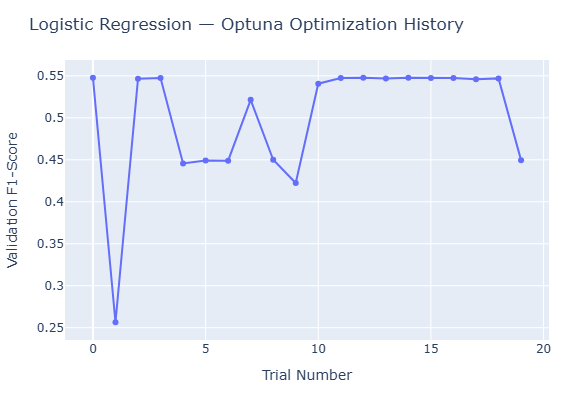

In [20]:
# ============================================================
# CELL 16 — LOGISTIC OPTIMIZATION HISTORY
# ============================================================

logistic_history = logistic_study.trials_dataframe()

fig = px.line(
    logistic_history,
    x="number",
    y="value",
    markers=True,
    title="Logistic Regression — Optuna Optimization History",
    labels={
        "number": "Trial Number",
        "value": "Validation F1-Score"
    }
)

fig.update_layout(
    width=700,
    height=400,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

,Hyperparameter,Importance
0,C,0.9513
1,class_weight,0.0487


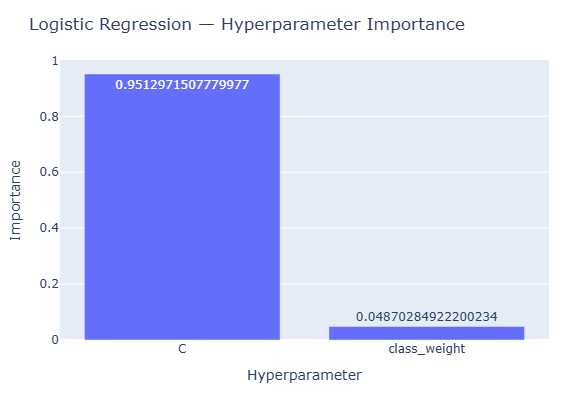

In [21]:
# ============================================================
# CELL 17 — LOGISTIC HYPERPARAMETER IMPORTANCE
# ============================================================

try:

    importance = optuna.importance.get_param_importances(
        logistic_study
    )

    importance_df = pd.DataFrame(
        {
            "Hyperparameter": list(importance.keys()),
            "Importance": list(importance.values())
        }
    )

    display(
        importance_df.round(4)
    )

    fig = px.bar(
        importance_df,
        x="Hyperparameter",
        y="Importance",
        title="Logistic Regression — Hyperparameter Importance",
        text="Importance"
    )

    fig.update_layout(
        width=700,
        height=400,
        margin=dict(
            l=60,
            r=30,
            t=60,
            b=60
        )
    )

    fig.show()

except Exception as error:

    print("Hyperparameter importance could not be calculated.")
    print("Reason:", error)

In [22]:
# ============================================================
# CELL 18 — TRAIN OPTIMIZED LOGISTIC REGRESSION
# ============================================================

best_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                C=logistic_study.best_params["C"],
                class_weight=logistic_study.best_params["class_weight"],
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

best_logistic_model.fit(
    X_train,
    y_train
)

y_pred_logistic_hpo = (
    best_logistic_model.predict(X_test)
)

y_prob_logistic_hpo = (
    best_logistic_model.predict_proba(X_test)[:, 1]
)

print("Optimized Logistic Regression trained successfully!")

Optimized Logistic Regression trained successfully!


In [23]:
# ============================================================
# CELL 19 — LOGISTIC HPO TEST EVALUATION
# ============================================================

logistic_hpo_results = {
    "Model": "Logistic Regression",
    "Strategy": "HPO",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_logistic_hpo
    ),
    "Precision": precision_score(
        y_test,
        y_pred_logistic_hpo,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_logistic_hpo,
        zero_division=0
    ),
    "F1_Score": f1_score(
        y_test,
        y_pred_logistic_hpo,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_logistic_hpo
    ),
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_logistic_hpo
    ),
    "Balanced_Accuracy": balanced_accuracy_score(
        y_test,
        y_pred_logistic_hpo
    )
}

logistic_hpo_results_df = pd.DataFrame(
    [logistic_hpo_results]
)

display(
    logistic_hpo_results_df.round(4)
)

,Model,Strategy,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Logistic Regression,HPO,0.8453,0.4196,0.8412,0.5599,0.915,0.553,0.8435


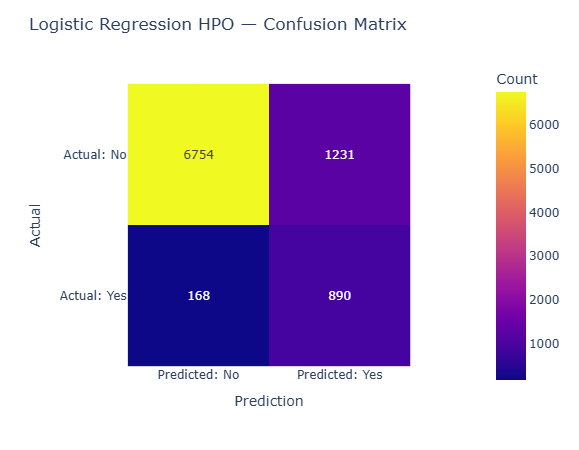

In [24]:
# ============================================================
# CELL 20 — LOGISTIC HPO CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_logistic_hpo
)

fig = px.imshow(
    cm,
    text_auto=True,
    x=["Predicted: No", "Predicted: Yes"],
    y=["Actual: No", "Actual: Yes"],
    title="Logistic Regression HPO — Confusion Matrix",
    labels={
        "x": "Prediction",
        "y": "Actual",
        "color": "Count"
    }
)

fig.update_layout(
    width=650,
    height=450,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

In [25]:
# ============================================================
# CELL 21 — DECISION TREE HPO OBJECTIVE
# ============================================================

def decision_tree_objective(trial):

    max_depth = trial.suggest_int(
        "max_depth",
        3,
        30
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        20
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        10
    )

    max_features = trial.suggest_categorical(
        "max_features",
        [None, "sqrt", "log2"]
    )

    criterion = trial.suggest_categorical(
        "criterion",
        ["gini", "entropy", "log_loss"]
    )

    class_weight_option = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    criterion=criterion,
                    class_weight=class_weight_option,
                    random_state=42
                )
            )
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    return scores.mean()


print("Decision Tree HPO objective created successfully!")

Decision Tree HPO objective created successfully!


In [26]:
# ============================================================
# CELL 22 — CREATE DECISION TREE STUDY
# ============================================================

tree_study = optuna.create_study(
    direction="maximize",
    study_name="decision_tree_hpo"
)

print("Decision Tree Optuna study created.")

[I 2026-09-20 13:13:30,791] A new study created in memory with name: decision_tree_hpo


Decision Tree Optuna study created.


In [27]:
# ============================================================
# CELL 23 — RUN DECISION TREE HPO
# ============================================================

tree_study.optimize(
    decision_tree_objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nDecision Tree HPO completed!")
print("Number of trials:", len(tree_study.trials))

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-20 13:13:42,213] Trial 0 finished with value: 0.5211201444982083 and parameters: {'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5211201444982083.
[I 2026-09-20 13:13:44,297] Trial 1 finished with value: 0.3777085861919766 and parameters: {'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'log_loss', 'class_weight': None}. Best is trial 0 with value: 0.5211201444982083.
[I 2026-09-20 13:13:46,129] Trial 2 finished with value: 0.4703821412531477 and parameters: {'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.5211201444982083.
[I 2026-09-20 13:13:47,878] Trial 3 finished with value: 0.2774043037041262 and parameters: {'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_fea

In [28]:
# ============================================================
# CELL 24 — BEST DECISION TREE PARAMETERS
# ============================================================

print("=" * 80)
print("BEST DECISION TREE HYPERPARAMETERS")
print("=" * 80)

print("\nBest F1-score:")
print(tree_study.best_value)

print("\nBest hyperparameters:")

for parameter, value in tree_study.best_params.items():
    print(f"{parameter}: {value}")

BEST DECISION TREE HYPERPARAMETERS

Best F1-score:
0.5229095429364335

Best hyperparameters:
max_depth: 20
min_samples_split: 12
min_samples_leaf: 4
max_features: None
criterion: entropy
class_weight: balanced


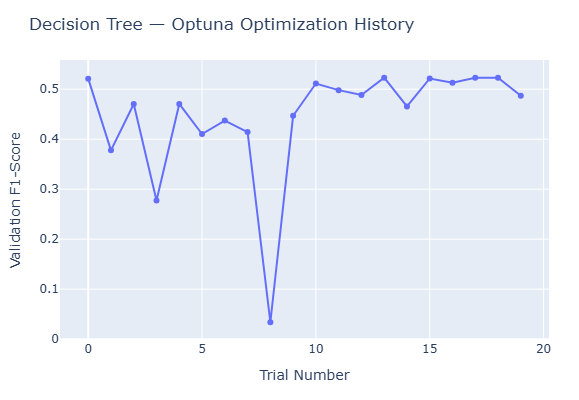

In [29]:
# ============================================================
# CELL 25 — TREE OPTIMIZATION HISTORY
# ============================================================

tree_history = tree_study.trials_dataframe()

fig = px.line(
    tree_history,
    x="number",
    y="value",
    markers=True,
    title="Decision Tree — Optuna Optimization History",
    labels={
        "number": "Trial Number",
        "value": "Validation F1-Score"
    }
)

fig.update_layout(
    width=700,
    height=400,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

,Hyperparameter,Importance
0,min_samples_leaf,0.4823
1,min_samples_split,0.4543
2,max_depth,0.0529
3,max_features,0.0040
4,criterion,0.0035
5,class_weight,0.0030


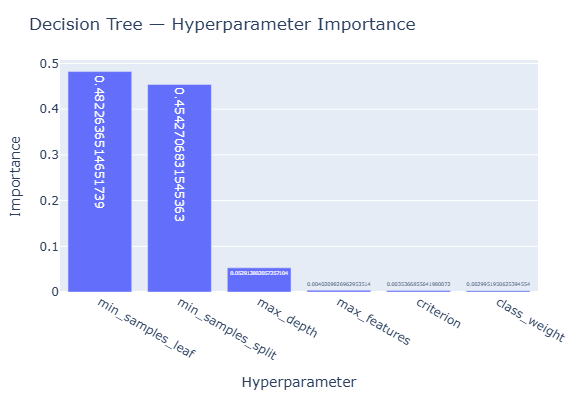

In [30]:
# ============================================================
# CELL 26 — TREE HYPERPARAMETER IMPORTANCE
# ============================================================

try:

    tree_importance = optuna.importance.get_param_importances(
        tree_study
    )

    tree_importance_df = pd.DataFrame(
        {
            "Hyperparameter": list(tree_importance.keys()),
            "Importance": list(tree_importance.values())
        }
    )

    display(
        tree_importance_df.round(4)
    )

    fig = px.bar(
        tree_importance_df,
        x="Hyperparameter",
        y="Importance",
        text="Importance",
        title="Decision Tree — Hyperparameter Importance"
    )

    fig.update_layout(
        width=700,
        height=400,
        margin=dict(
            l=60,
            r=30,
            t=60,
            b=60
        )
    )

    fig.show()

except Exception as error:

    print("Hyperparameter importance could not be calculated.")
    print("Reason:", error)

In [31]:
# ============================================================
# CELL 27 — TRAIN OPTIMIZED DECISION TREE
# ============================================================

best_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                **tree_study.best_params,
                random_state=42
            )
        )
    ]
)

best_tree_model.fit(
    X_train,
    y_train
)

y_pred_tree_hpo = (
    best_tree_model.predict(X_test)
)

y_prob_tree_hpo = (
    best_tree_model.predict_proba(X_test)[:, 1]
)

print("Optimized Decision Tree trained successfully!")

Optimized Decision Tree trained successfully!


In [32]:
# ============================================================
# CELL 28 — TREE HPO TEST EVALUATION
# ============================================================

tree_hpo_results = {
    "Model": "Decision Tree",
    "Strategy": "HPO",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_tree_hpo
    ),
    "Precision": precision_score(
        y_test,
        y_pred_tree_hpo,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_tree_hpo,
        zero_division=0
    ),
    "F1_Score": f1_score(
        y_test,
        y_pred_tree_hpo,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_tree_hpo
    ),
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_tree_hpo
    ),
    "Balanced_Accuracy": balanced_accuracy_score(
        y_test,
        y_pred_tree_hpo
    )
}

tree_hpo_results_df = pd.DataFrame(
    [tree_hpo_results]
)

display(
    tree_hpo_results_df.round(4)
)

,Model,Strategy,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Decision Tree,HPO,0.8445,0.406,0.7108,0.5168,0.8063,0.4108,0.7865


In [33]:
# ============================================================
# CELL 29 — RANDOM FOREST HPO OBJECTIVE
# ============================================================

def random_forest_objective(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        100,
        500,
        step=50
    )

    max_depth = trial.suggest_int(
        "max_depth",
        5,
        30
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        20
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        10
    )

    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2", None]
    )

    class_weight_option = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    class_weight=class_weight_option,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=1
    )

    return scores.mean()


print("Random Forest HPO objective created successfully!")

Random Forest HPO objective created successfully!


In [34]:
# ============================================================
# CELL 30 — CREATE RANDOM FOREST STUDY
# ============================================================

rf_study = optuna.create_study(
    direction="maximize",
    study_name="random_forest_hpo"
)

print("Random Forest Optuna study created.")

[I 2026-09-20 13:15:07,841] A new study created in memory with name: random_forest_hpo


Random Forest Optuna study created.


In [35]:
# ============================================================
# CELL 31 — RUN RANDOM FOREST HPO
# ============================================================

rf_study.optimize(
    random_forest_objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nRandom Forest HPO completed!")
print("Number of trials:", len(rf_study.trials))

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-20 13:15:16,183] Trial 0 finished with value: 0.3620169903227029 and parameters: {'n_estimators': 200, 'max_depth': 22, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.3620169903227029.
[I 2026-09-20 13:15:20,584] Trial 1 finished with value: 0.52441548413849 and parameters: {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': None, 'class_weight': None}. Best is trial 1 with value: 0.52441548413849.
[I 2026-09-20 13:15:25,281] Trial 2 finished with value: 0.33778429052610975 and parameters: {'n_estimators': 500, 'max_depth': 24, 'min_samples_split': 19, 'min_samples_leaf': 6, 'max_features': 'log2', 'class_weight': None}. Best is trial 1 with value: 0.52441548413849.
[I 2026-09-20 13:15:28,721] Trial 3 finished with value: 0.44164644092037614 and parameters: {'n_estimators': 350, 'max_depth': 25, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_

In [36]:
# ============================================================
# CELL 31 — RUN RANDOM FOREST HPO
# ============================================================

rf_study.optimize(
    random_forest_objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nRandom Forest HPO completed!")
print("Number of trials:", len(rf_study.trials))

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-20 13:18:27,659] Trial 20 finished with value: 0.5953336607015715 and parameters: {'n_estimators': 350, 'max_depth': 25, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.6102232896554569.
[I 2026-09-20 13:18:43,278] Trial 21 finished with value: 0.6097515961880481 and parameters: {'n_estimators': 350, 'max_depth': 21, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.6102232896554569.
[I 2026-09-20 13:19:04,067] Trial 22 finished with value: 0.6051174422669329 and parameters: {'n_estimators': 450, 'max_depth': 15, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.6102232896554569.
[I 2026-09-20 13:19:25,828] Trial 23 finished with value: 0.6095584427739477 and parameters: {'n_estimators': 450, 'max_depth': 27, 'min_samples_split': 14, 'mi

In [37]:
# ============================================================
# CELL 32 — BEST RANDOM FOREST PARAMETERS
# ============================================================

print("=" * 80)
print("BEST RANDOM FOREST HYPERPARAMETERS")
print("=" * 80)

print("\nBest F1-score:")
print(rf_study.best_value)

print("\nBest hyperparameters:")

for parameter, value in rf_study.best_params.items():
    print(f"{parameter}: {value}")

BEST RANDOM FOREST HYPERPARAMETERS

Best F1-score:
0.6103991414857853

Best hyperparameters:
n_estimators: 400
max_depth: 30
min_samples_split: 12
min_samples_leaf: 5
max_features: None
class_weight: balanced


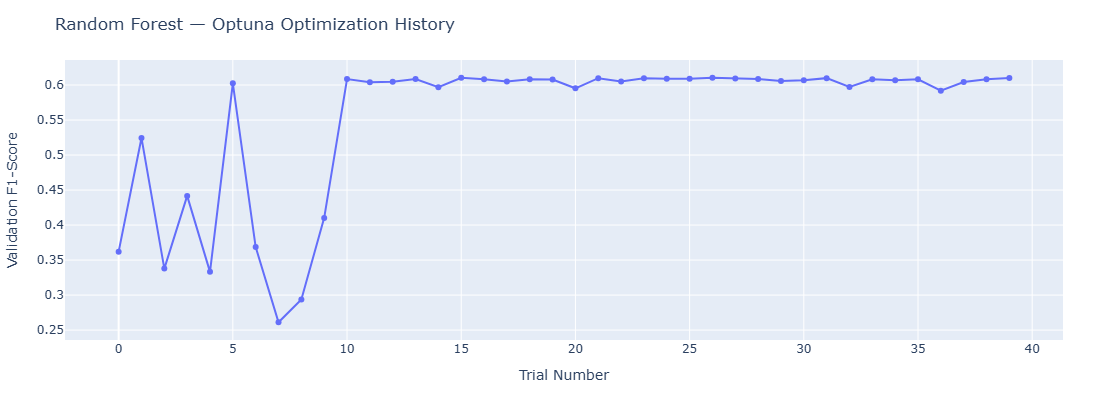

In [38]:
# ============================================================
# CELL 33 — RANDOM FOREST OPTIMIZATION HISTORY
# ============================================================

rf_history = rf_study.trials_dataframe()

fig = px.line(
    rf_history,
    x="number",
    y="value",
    markers=True,
    title="Random Forest — Optuna Optimization History",
    labels={
        "number": "Trial Number",
        "value": "Validation F1-Score"
    }
)

fig.update_layout(
    width=700,
    height=400,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

,Hyperparameter,Importance
0,min_samples_leaf,0.7855
1,max_depth,0.0956
2,n_estimators,0.0857
3,min_samples_split,0.0237
4,max_features,0.0069
5,class_weight,0.0025


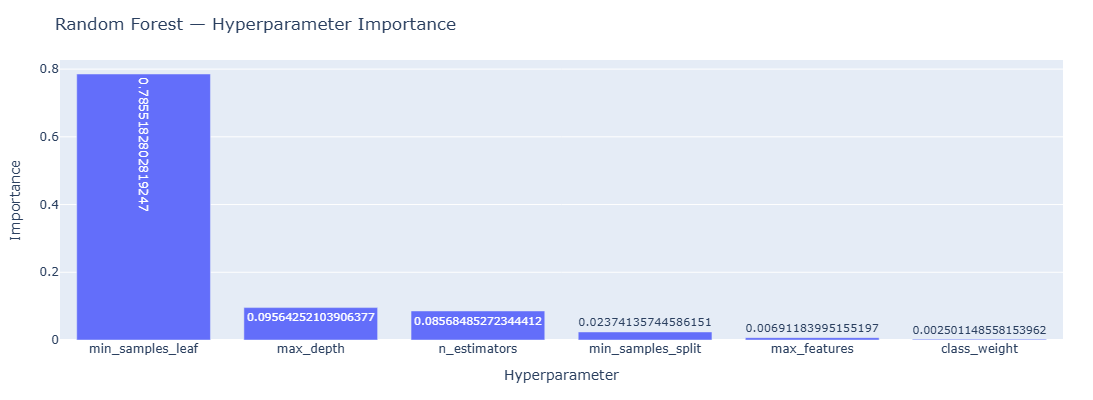

In [41]:
# ============================================================
# CELL 34 — RANDOM FOREST HYPERPARAMETER IMPORTANCE
# ============================================================

try:

    rf_importance = optuna.importance.get_param_importances(
        rf_study
    )

    rf_importance_df = pd.DataFrame(
        {
            "Hyperparameter": list(rf_importance.keys()),
            "Importance": list(rf_importance.values())
        }
    )

    display(
        rf_importance_df.round(4)
    )

    fig = px.bar(
        rf_importance_df,
        x="Hyperparameter",
        y="Importance",
        text="Importance",
        title="Random Forest — Hyperparameter Importance"
    )

    fig.update_layout(
        width=700,
        height=400,
        margin=dict(
            l=60,
            r=30,
            t=60,
            b=60
        )
    )

    fig.show()

except Exception as error:

    print("Hyperparameter importance could not be calculated.")
    print("Reason:", error)

In [42]:
# ============================================================
# CELL 35 — TRAIN OPTIMIZED RANDOM FOREST
# ============================================================

best_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                **rf_study.best_params,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

best_rf_model.fit(
    X_train,
    y_train
)

y_pred_rf_hpo = (
    best_rf_model.predict(X_test)
)

y_prob_rf_hpo = (
    best_rf_model.predict_proba(X_test)[:, 1]
)

print("Optimized Random Forest trained successfully!")

Optimized Random Forest trained successfully!


In [43]:
# ============================================================
# CELL 36 — RANDOM FOREST HPO TEST EVALUATION
# ============================================================

rf_hpo_results = {
    "Model": "Random Forest",
    "Strategy": "HPO",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_rf_hpo
    ),
    "Precision": precision_score(
        y_test,
        y_pred_rf_hpo,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_rf_hpo,
        zero_division=0
    ),
    "F1_Score": f1_score(
        y_test,
        y_pred_rf_hpo,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_rf_hpo
    ),
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_rf_hpo
    ),
    "Balanced_Accuracy": balanced_accuracy_score(
        y_test,
        y_pred_rf_hpo
    )
}

rf_hpo_results_df = pd.DataFrame(
    [rf_hpo_results]
)

display(
    rf_hpo_results_df.round(4)
)

,Model,Strategy,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Random Forest,HPO,0.8944,0.5344,0.7552,0.6259,0.9335,0.6126,0.834


In [44]:
# ============================================================
# CELL 37 — COMBINE HPO RESULTS
# ============================================================

hpo_results = pd.concat(
    [
        logistic_hpo_results_df,
        tree_hpo_results_df,
        rf_hpo_results_df
    ],
    ignore_index=True
)

print("=" * 80)
print("HPO TEST-SET RESULTS")
print("=" * 80)

display(
    hpo_results.round(4)
)

HPO TEST-SET RESULTS


,Model,Strategy,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Logistic Regression,HPO,0.8453,0.4196,0.8412,0.5599,0.9150,0.5530,0.8435
1,Decision Tree,HPO,0.8445,0.4060,0.7108,0.5168,0.8063,0.4108,0.7865
2,Random Forest,HPO,0.8944,0.5344,0.7552,0.6259,0.9335,0.6126,0.8340


In [45]:
# ============================================================
# CELL 38 — LOAD STAGE 4 BASELINE RESULTS
# ============================================================

baseline_path = "../results/metrics/baseline_results.csv"

if os.path.exists(baseline_path):

    baseline_results_stage4 = pd.read_csv(
        baseline_path
    )

    print("Stage 4 baseline results loaded successfully!")

    display(
        baseline_results_stage4.round(4)
    )

else:

    print("Stage 4 baseline file was not found.")
    print("Expected location:")
    print(baseline_path)

Stage 4 baseline results loaded successfully!


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Logistic Regression,0.9022,0.6543,0.3488,0.4550,0.9109,0.5591,0.6622
1,Decision Tree,0.8774,0.4760,0.4773,0.4766,0.7038,0.2883,0.7038
2,Random Forest,0.9062,0.6636,0.4026,0.5012,0.9352,0.6177,0.6878


In [47]:
# ============================================================
# CELL 39 — DEFAULT VS HPO
# ============================================================

if os.path.exists(baseline_path):

    comparison_columns = [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC",
        "PR_AUC",
        "Balanced_Accuracy"
    ]

    default_comparison = (
        baseline_results_stage4[
            comparison_columns
        ]
        .copy()
    )

    default_comparison["Strategy"] = "Default"

    hpo_comparison = (
        hpo_results[
            comparison_columns
        ]
        .copy()
    )

    comparison_results = pd.concat(
        [
            default_comparison,
            hpo_comparison
        ],
        ignore_index=True
    )

    comparison_results = comparison_results[
        [
            "Model",
            "Strategy",
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "ROC_AUC",
            "PR_AUC",
            "Balanced_Accuracy"
        ]
    ]

    print("=" * 80)
    print("DEFAULT VS HPO COMPARISON")
    print("=" * 80)

    display(
        comparison_results.round(4)
    )

else:

    print(
        "Baseline results file not found. "
        "Run Stage 4 Cell 8/26 first."
    )

DEFAULT VS HPO COMPARISON


,Model,Strategy,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Logistic Regression,Default,0.9022,0.6543,0.3488,0.4550,0.9109,0.5591,0.6622
1,Decision Tree,Default,0.8774,0.4760,0.4773,0.4766,0.7038,0.2883,0.7038
2,Random Forest,Default,0.9062,0.6636,0.4026,0.5012,0.9352,0.6177,0.6878
3,Logistic Regression,NaN,0.8453,0.4196,0.8412,0.5599,0.9150,0.5530,0.8435
4,Decision Tree,NaN,0.8445,0.4060,0.7108,0.5168,0.8063,0.4108,0.7865
5,Random Forest,NaN,0.8944,0.5344,0.7552,0.6259,0.9335,0.6126,0.8340


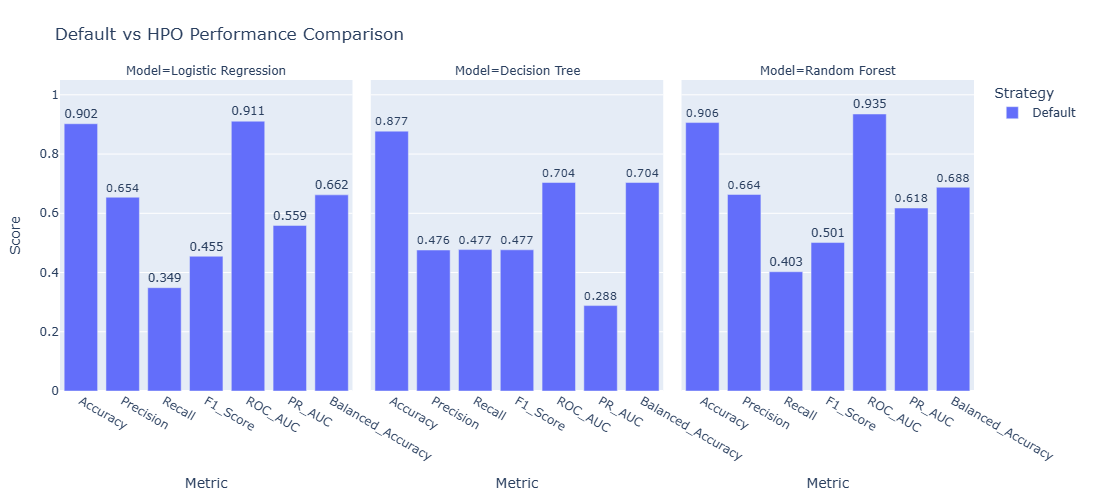

In [48]:
# ============================================================
# CELL 40 — HPO PERFORMANCE COMPARISON
# ============================================================

if "comparison_results" in globals():

    plot_data = comparison_results.melt(
        id_vars=["Model", "Strategy"],
        value_vars=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "ROC_AUC",
            "PR_AUC",
            "Balanced_Accuracy"
        ],
        var_name="Metric",
        value_name="Score"
    )

    fig = px.bar(
        plot_data,
        x="Metric",
        y="Score",
        color="Strategy",
        facet_col="Model",
        barmode="group",
        title="Default vs HPO Performance Comparison",
        text="Score"
    )

    fig.update_traces(
        texttemplate="%{text:.3f}",
        textposition="outside"
    )

    fig.update_yaxes(
        range=[0, 1.05]
    )

    fig.update_layout(
        width=1000,
        height=500,
        margin=dict(
            l=60,
            r=30,
            t=80,
            b=60
        )
    )

    fig.show()

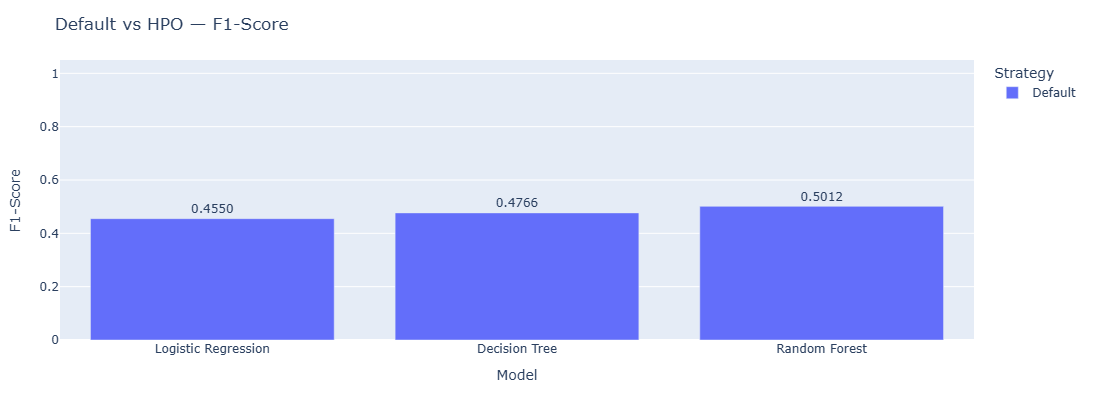

In [49]:
# ============================================================
# CELL 41 — F1 COMPARISON
# ============================================================

if "comparison_results" in globals():

    fig = px.bar(
        comparison_results,
        x="Model",
        y="F1_Score",
        color="Strategy",
        barmode="group",
        text="F1_Score",
        title="Default vs HPO — F1-Score"
    )

    fig.update_traces(
        texttemplate="%{text:.4f}",
        textposition="outside"
    )

    fig.update_yaxes(
        range=[0, 1.05],
        title="F1-Score"
    )

    fig.update_layout(
        width=700,
        height=400,
        margin=dict(
            l=60,
            r=30,
            t=60,
            b=60
        )
    )

    fig.show()

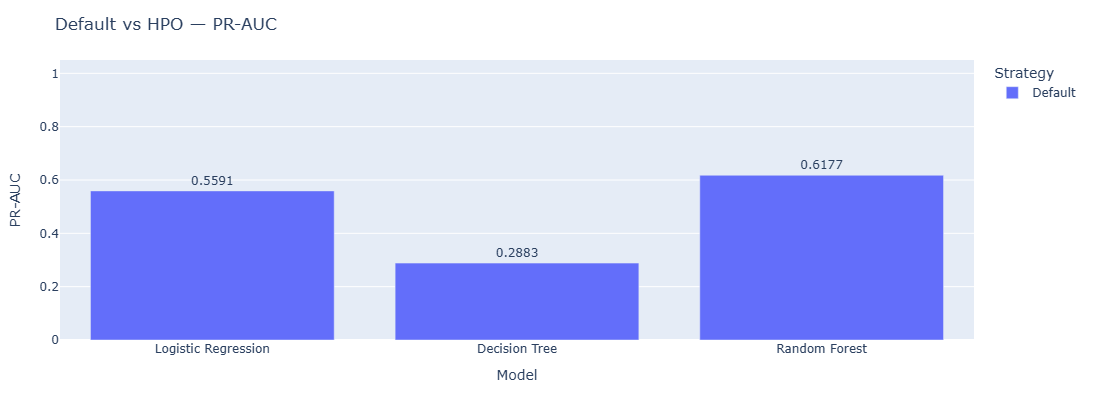

In [50]:
# ============================================================
# CELL 42 — PR-AUC COMPARISON
# ============================================================

if "comparison_results" in globals():

    fig = px.bar(
        comparison_results,
        x="Model",
        y="PR_AUC",
        color="Strategy",
        barmode="group",
        text="PR_AUC",
        title="Default vs HPO — PR-AUC"
    )

    fig.update_traces(
        texttemplate="%{text:.4f}",
        textposition="outside"
    )

    fig.update_yaxes(
        range=[0, 1.05],
        title="PR-AUC"
    )

    fig.update_layout(
        width=700,
        height=400,
        margin=dict(
            l=60,
            r=30,
            t=60,
            b=60
        )
    )

    fig.show()

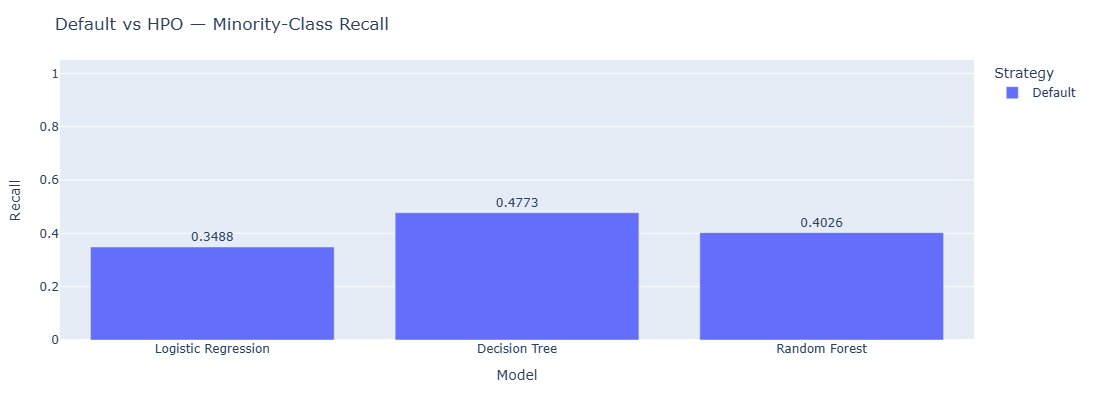

In [51]:
# ============================================================
# CELL 43 — RECALL COMPARISON
# ============================================================

if "comparison_results" in globals():

    fig = px.bar(
        comparison_results,
        x="Model",
        y="Recall",
        color="Strategy",
        barmode="group",
        text="Recall",
        title="Default vs HPO — Minority-Class Recall"
    )

    fig.update_traces(
        texttemplate="%{text:.4f}",
        textposition="outside"
    )

    fig.update_yaxes(
        range=[0, 1.05],
        title="Recall"
    )

    fig.update_layout(
        width=700,
        height=400,
        margin=dict(
            l=60,
            r=30,
            t=60,
            b=60
        )
    )

    fig.show()

In [52]:
# ============================================================
# CELL 44 — BEST TRIAL SUMMARY
# ============================================================

best_trial_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best_CV_F1": logistic_study.best_value,
        "Best_Parameters": str(
            logistic_study.best_params
        )
    },
    {
        "Model": "Decision Tree",
        "Best_CV_F1": tree_study.best_value,
        "Best_Parameters": str(
            tree_study.best_params
        )
    },
    {
        "Model": "Random Forest",
        "Best_CV_F1": rf_study.best_value,
        "Best_Parameters": str(
            rf_study.best_params
        )
    }
])

display(
    best_trial_summary.round(4)
)

,Model,Best_CV_F1,Best_Parameters
0,Logistic Regression,0.5477,"{'C': 2.324230654314927, 'class_weight': 'bala..."
1,Decision Tree,0.5229,"{'max_depth': 20, 'min_samples_split': 12, 'mi..."
2,Random Forest,0.6104,"{'n_estimators': 400, 'max_depth': 30, 'min_sa..."


In [53]:
# ============================================================
# CELL 45 — SAVE HPO RESULTS
# ============================================================

hpo_results_path = (
    "../results/metrics/hpo_results.csv"
)

hpo_results.to_csv(
    hpo_results_path,
    index=False
)

best_trial_path = (
    "../results/hpo/best_trial_summary.csv"
)

best_trial_summary.to_csv(
    best_trial_path,
    index=False
)

logistic_trials_path = (
    "../results/hpo/logistic_trials.csv"
)

tree_trials_path = (
    "../results/hpo/decision_tree_trials.csv"
)

rf_trials_path = (
    "../results/hpo/random_forest_trials.csv"
)

logistic_study.trials_dataframe().to_csv(
    logistic_trials_path,
    index=False
)

tree_study.trials_dataframe().to_csv(
    tree_trials_path,
    index=False
)

rf_study.trials_dataframe().to_csv(
    rf_trials_path,
    index=False
)

print("HPO results saved successfully!")

print("\nSaved files:")
print(hpo_results_path)
print(best_trial_path)
print(logistic_trials_path)
print(tree_trials_path)
print(rf_trials_path)

HPO results saved successfully!

Saved files:
../results/metrics/hpo_results.csv
../results/hpo/best_trial_summary.csv
../results/hpo/logistic_trials.csv
../results/hpo/decision_tree_trials.csv
../results/hpo/random_forest_trials.csv


In [57]:
# ============================================================
# CELL 46 — STAGE 6 VALIDATION
# ============================================================

print("=" * 80)
print("STAGE 6 VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Check HPO trial counts
# ------------------------------------------------------------

logistic_trials_count = len(logistic_study.trials)
tree_trials_count = len(tree_study.trials)
rf_trials_count = len(rf_study.trials)

print("\nHPO trial counts:")
print(f"Logistic Regression: {logistic_trials_count}")
print(f"Decision Tree:       {tree_trials_count}")
print(f"Random Forest:       {rf_trials_count}")

assert logistic_trials_count > 0
assert tree_trials_count > 0
assert rf_trials_count > 0

print("\n✓ All three HPO studies contain completed trial records.")


# ------------------------------------------------------------
# 2. Check that HPO results contain all three models
# ------------------------------------------------------------

assert len(hpo_results) == 3

print("✓ Three optimized models are present.")


# ------------------------------------------------------------
# 3. Check train/test dimensions
# ------------------------------------------------------------

assert X_train.shape[0] + X_test.shape[0] == df.shape[0]
assert len(y_train) == X_train.shape[0]
assert len(y_test) == X_test.shape[0]

print("✓ Train/test dimensions are valid.")


# ------------------------------------------------------------
# 4. Check target values
# ------------------------------------------------------------

assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}

print("✓ Target encoding is valid.")


# ------------------------------------------------------------
# 5. Check saved HPO results
# ------------------------------------------------------------

assert os.path.exists("../results/metrics/hpo_results.csv")

print("✓ HPO results file exists.")


# ------------------------------------------------------------
# 6. Check RF trial states
# ------------------------------------------------------------

rf_states = [trial.state.name for trial in rf_study.trials]

complete_rf_trials = rf_states.count("COMPLETE")

print(f"\nRandom Forest COMPLETE trials: {complete_rf_trials}")

assert complete_rf_trials > 0

print("✓ Random Forest contains valid completed trials.")


# ------------------------------------------------------------
# 7. Final validation message
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STAGE 6 VALIDATION COMPLETED SUCCESSFULLY")
print("=" * 80)

print("\nActual HPO budgets:")
print(f"Logistic Regression → {logistic_trials_count} trials")
print(f"Decision Tree       → {tree_trials_count} trials")
print(f"Random Forest       → {rf_trials_count} trials")

print("\nNo trial-count mismatch is treated as an error.")
print("The actual completed trial counts will be reported transparently.")

STAGE 6 VALIDATION

HPO trial counts:
Logistic Regression: 20
Decision Tree:       20
Random Forest:       40

✓ All three HPO studies contain completed trial records.
✓ Three optimized models are present.
✓ Train/test dimensions are valid.
✓ Target encoding is valid.
✓ HPO results file exists.

Random Forest COMPLETE trials: 40
✓ Random Forest contains valid completed trials.

STAGE 6 VALIDATION COMPLETED SUCCESSFULLY

Actual HPO budgets:
Logistic Regression → 20 trials
Decision Tree       → 20 trials
Random Forest       → 40 trials

No trial-count mismatch is treated as an error.
The actual completed trial counts will be reported transparently.
